### fruits를 kNN으로 분류하기

In [1]:
import pandas as pd

fruits = pd.read_csv("../Data/fruits.csv")
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


#### Feature와 Target을 Numpy Array로 변경

In [2]:
# 연습 : numpy의 column stack과 row stack
# array는 숫자면 숫자, 문자면 문자만 들어가야한다.
import numpy as np
testA = np.array([1,2,3,4])
testB = np.array([10,20,30,40])

# 2개의 값을 묶어서 컬럼기반의 하나의 Array로 만들기
combineA = [[i,j] for i, j in zip(testA, testB)]
print(np.array(combineA))


# 다른 방법
combineB = np.column_stack((testA,testB))
print(combineB)


# Row 기준
combineC = np.row_stack((testA,testB))
print(combineC)

[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
[[ 1  2  3  4]
 [10 20 30 40]]


In [3]:
fruits_data = np.column_stack((fruits.length, fruits.weight))
fruits_data[:5]

array([[ 25.4, 242. ],
       [ 26.3, 290. ],
       [ 26.5, 340. ],
       [ 29. , 363. ],
       [ 29. , 430. ]])

In [4]:
fruits_target = np.array(fruits['name'])
fruits_target[:5]

array(['apple', 'apple', 'apple', 'apple', 'apple'], dtype=object)

#### sklearn으로 Tarin Set과 Test Set으로 나누기

In [5]:
from sklearn.model_selection import train_test_split
import collections # 빈도수 세기

In [6]:
train_input, test_input, train_target, test_target = \
  train_test_split(
    fruits_data,
    fruits_target,
    random_state=42,
    stratify=fruits_target
  )

In [7]:
print(train_input.shape)
print(test_input.shape)
print(train_target.shape)
print(test_target.shape)

(36, 2)
(13, 2)
(36,)
(13,)


In [8]:
train_counts = collections.Counter(train_target)
train_counts['apple'] / train_counts['berry']

2.6

In [9]:
test_counts = collections.Counter(test_target)
test_counts['apple'] / test_counts['berry']

2.25

In [10]:
len(fruits[fruits.name == 'apple']) / \
  len(fruits[fruits.name == 'berry'])

2.5

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Set n_neighbors to 3, since train_input has 3 samples
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_input, train_target)
print("Train score:", kn.score(train_input, train_target))
print("Test score:", kn.score(test_input, test_target))
kn.score

Train score: 1.0
Test score: 1.0


<bound method ClassifierMixin.score of KNeighborsClassifier(n_neighbors=3)>

In [12]:
temp = fruits.loc[:,['length','weight']]
temp.values

array([[  25.4,  242. ],
       [  26.3,  290. ],
       [  26.5,  340. ],
       [  29. ,  363. ],
       [  29. ,  430. ],
       [  29.7,  450. ],
       [  29.7,  500. ],
       [  30. ,  390. ],
       [  30. ,  450. ],
       [  30.7,  500. ],
       [  31. ,  475. ],
       [  31. ,  500. ],
       [  31.5,  500. ],
       [  32. ,  340. ],
       [  32. ,  600. ],
       [  32. ,  600. ],
       [  33. ,  700. ],
       [  33. ,  700. ],
       [  33.5,  610. ],
       [  33.5,  650. ],
       [  34. ,  575. ],
       [  34. ,  685. ],
       [  34.5,  620. ],
       [  35. ,  680. ],
       [  35. ,  700. ],
       [  35. ,  725. ],
       [  35. ,  720. ],
       [  36. ,  714. ],
       [  36. ,  850. ],
       [  37. , 1000. ],
       [  38.5,  920. ],
       [  38.5,  955. ],
       [  39.5,  925. ],
       [  41. ,  975. ],
       [  41. ,  950. ],
       [   9.8,    6.7],
       [  10.5,    7.5],
       [  10.6,    7. ],
       [  11. ,    9.7],
       [  11.2,    9.8],


In [13]:
# length : 25, weight : 150
kn.predict([[25, 150]])


array(['berry'], dtype=object)

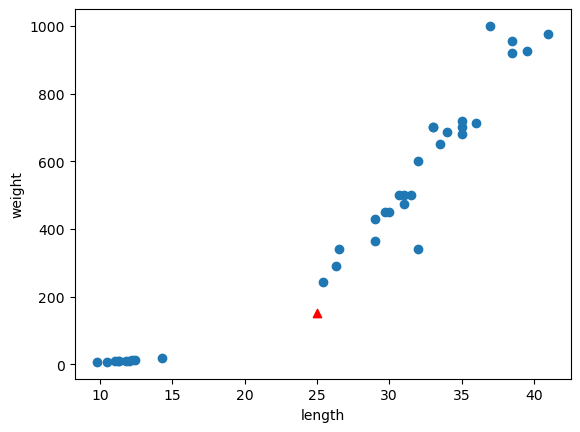

In [14]:
import matplotlib.pyplot as plt

plt.scatter(
    train_input[:,0],
    train_input[:,1]
)
plt.scatter(
    25,
    150,
    marker='^',
    c='red'
)

plt.xlabel('length')
plt.ylabel('weight')

plt.show()

### 이웃을 출력해보자

In [15]:
distances, indexes = kn.kneighbors([[25,150]])
print(indexes)

[[11 20 13]]


In [16]:
train_input[indexes]

array([[[ 25.4, 242. ],
        [ 14.3,  19.7],
        [ 12.4,  13.4]]])

### 산포도로 이웃을 출력

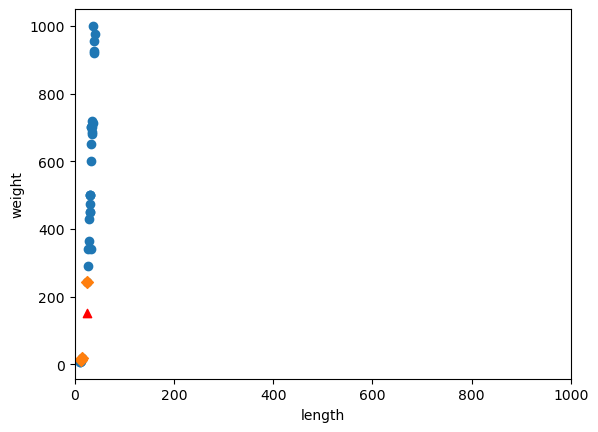

In [17]:
plt.scatter(
    train_input[:,0],
    train_input[:,1]
)
plt.scatter(
    25,
    150,
    marker='^',
    c='red'
)

plt.scatter(
    train_input[indexes, 0],
    train_input[indexes, 1],
    marker='D'
)

plt.xlim(0, 1000) # 기준 맞춰 정규화 해주기
plt.xlabel('length')
plt.ylabel('weight')

plt.show()

> 샘플이 length에는 거의 영향을 받지 않고 weight에서 영향을 많이 받는다

In [18]:
# 이웃의 Target를 출력

train_target[indexes]

array([['apple', 'berry', 'berry']], dtype=object)

---
### 기준을 맞추자

In [19]:
# length와 weight의 평균과 표준편차를 구해서 비교해보자

mean = fruits[['length', 'weight']].mean()
print('평균:', mean)

std = fruits[['length', 'weight']].std()
print('표준편차:', std)

#----------------위아래 둘다 맞음(아래 추천)----------------------

mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)

print(mean, std)

평균: length     27.055102
weight    444.500000
dtype: float64
표준편차: length     10.242804
weight    328.143233
dtype: float64
[ 26.93333333 441.98333333] [ 10.09141549 325.61300692]


> sample이 length에는 거의 영향을 받지 않고 weight에서 영향을 많이 받는다.

#### train_data를 표준화(Z-점수)
표준점수 = (Feature - 평균) / 표준편차

In [20]:
train_scaled = (train_input - mean) / std
train_scaled
# 표준화다 정규화 아니다.

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137],
       [ 1.14618873,  1.46805151],
       [-1.49962444, -1.32698425],
       [ 0.50207691,  0.48528979],
       [-1.47980562, -1.32729137],
       [ 0.89845341,  0.83539865],
       [ 0.60117103,  0.79240283],
       [-0.15194433, -0.61417489],
       [ 0.99754754,  1.71374194],
       [-1.44016797, -1.3162353 ],
       [-1.69781269, -1.33681187],
       [-0.06275961, -0.46676063],
       [ 0.79935928,  0.73098022],
       [ 0.40298278,  0.17817675],
       [-1.57889974, -1.32759848],
       [ 0.27416042,  0.02462023],
       [-1.25188913, -1.29688718],
       [ 0.79935928,  0.79240283],
       [-1.45998679, -1.31992065],
       [ 0.45252984,  0.17817675],
       [ 1.39392404,  1.63696368],
       [ 0.6507181 ,  0.63884631],
       [ 0.60117103,  0.79240283],
       [-1.62844681, -1.33435497],
       [-0.04294079,

In [21]:
# sklearn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_input)
train_scaled2 = scaler.transform(train_input)
train_scaled2



array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137],
       [ 1.14618873,  1.46805151],
       [-1.49962444, -1.32698425],
       [ 0.50207691,  0.48528979],
       [-1.47980562, -1.32729137],
       [ 0.89845341,  0.83539865],
       [ 0.60117103,  0.79240283],
       [-0.15194433, -0.61417489],
       [ 0.99754754,  1.71374194],
       [-1.44016797, -1.3162353 ],
       [-1.69781269, -1.33681187],
       [-0.06275961, -0.46676063],
       [ 0.79935928,  0.73098022],
       [ 0.40298278,  0.17817675],
       [-1.57889974, -1.32759848],
       [ 0.27416042,  0.02462023],
       [-1.25188913, -1.29688718],
       [ 0.79935928,  0.79240283],
       [-1.45998679, -1.31992065],
       [ 0.45252984,  0.17817675],
       [ 1.39392404,  1.63696368],
       [ 0.6507181 ,  0.63884631],
       [ 0.60117103,  0.79240283],
       [-1.62844681, -1.33435497],
       [-0.04294079,

In [22]:
scaler = StandardScaler()

train_scaled2 = scaler.fit_transform(train_input)
train_scaled2

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137],
       [ 1.14618873,  1.46805151],
       [-1.49962444, -1.32698425],
       [ 0.50207691,  0.48528979],
       [-1.47980562, -1.32729137],
       [ 0.89845341,  0.83539865],
       [ 0.60117103,  0.79240283],
       [-0.15194433, -0.61417489],
       [ 0.99754754,  1.71374194],
       [-1.44016797, -1.3162353 ],
       [-1.69781269, -1.33681187],
       [-0.06275961, -0.46676063],
       [ 0.79935928,  0.73098022],
       [ 0.40298278,  0.17817675],
       [-1.57889974, -1.32759848],
       [ 0.27416042,  0.02462023],
       [-1.25188913, -1.29688718],
       [ 0.79935928,  0.79240283],
       [-1.45998679, -1.31992065],
       [ 0.45252984,  0.17817675],
       [ 1.39392404,  1.63696368],
       [ 0.6507181 ,  0.63884631],
       [ 0.60117103,  0.79240283],
       [-1.62844681, -1.33435497],
       [-0.04294079,

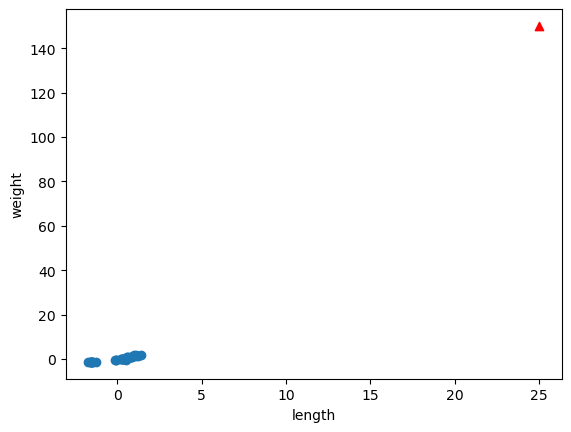

In [23]:
plt.scatter(
    train_scaled[:,0],
    train_scaled[:,1]
)
plt.scatter(
    25,
    150,
    marker='^',
    c='red'
)


plt.xlabel('length')
plt.ylabel('weight')

plt.show()

In [24]:
new = ([25, 150] - mean) / std
new

array([-0.19158198, -0.89671889])

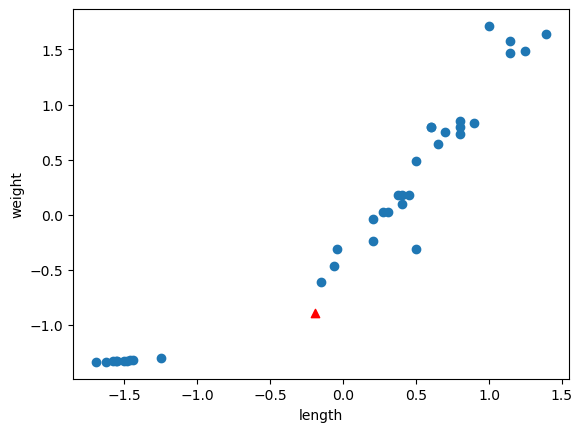

In [25]:
plt.scatter(
    train_scaled[:,0],
    train_scaled[:,1]
)
plt.scatter(
    new[0],
    new[1],
    marker='^',
    c='red'
)


plt.xlabel('length')
plt.ylabel('weight')

plt.show()

In [26]:
kn.fit(train_scaled, train_target)

KNeighborsClassifier(n_neighbors=3)

In [27]:
test_scaled = scaler.transform(test_input)
test_scaled

array([[ 0.79935928,  0.86918109],
       [ 0.74981222,  0.54671239],
       [ 1.39392404,  1.56018542],
       [-1.18252324, -1.29627295],
       [-1.38071149, -1.31992065],
       [ 0.6507181 ,  0.51600109],
       [-1.49962444, -1.32667714],
       [ 0.70026516,  0.40851153],
       [-1.61853739, -1.33589053],
       [ 0.89845341,  1.25307238],
       [ 0.30388865, -0.15964759],
       [ 0.50207691,  0.48528979],
       [ 0.27416042,  0.17817675]])

In [28]:
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

1.0
1.0


In [29]:
kn.predict([new])

array(['apple'], dtype=object)

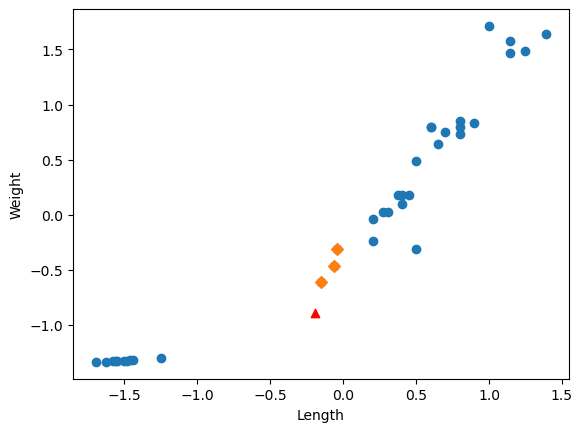

In [30]:
# 확인을 위해 이웃 출력하자
_, indexes = kn.kneighbors([new])

plt.scatter(
    train_scaled[:,0],
    train_scaled[:,1]
)
plt.scatter(
    new[0],
    new[1],
    marker='^',
    c='red'
)

plt.scatter(
    train_scaled[indexes, 0],
    train_scaled[indexes, 1],
    marker='D'
)


plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()